# Libraries

In [1]:
import pandas as pd
from pathlib import Path

# 1. Data loading

In [2]:
# BMS: Setting up on my local machine for now
BASE = Path('../../../CICCADA - Data/Tesla/datatank_telemetry_UNSW')

In [3]:
# Not that CPU has a capital D
folders = {
    'ausnet': (BASE / 'datatank_telemetry_ausnet', range(26, 51)),
    'cpu':    (BASE / 'Datatank_telemetry_CPU',    range(1, 26)),
    'sapn':   (BASE / 'datatank_telemetry_SAPN',   range(51, 101)),
}

In [6]:
# Aggregating all files into a single DataFrame
dfs = []
for region, (folder, sn_range) in folders.items():
    for sn in sn_range:
        sn_id = f'SN{sn:03d}'
        # prefer parquet, fall back to csv
        parquet_path = folder / f'{sn_id}_telemetry_60sec.parquet'
        csv_path     = folder / f'{sn_id}_telemetry_60sec.csv'
        path = parquet_path if parquet_path.exists() else csv_path
        
        try:
            df = pd.read_parquet(path) if path.suffix == '.parquet' else pd.read_csv(path)
            df['region'] = region  # ausnet / cpu / sapn
            dfs.append(df)
        except FileNotFoundError:
            print(f'Missing: {path}')

all_data = pd.concat(dfs, ignore_index=True)

# Fix types once, up front
all_data['timestamp'] = pd.to_datetime(all_data['timestamp'])
all_data['pseudonym'] = all_data['pseudonym'].astype('category')  # saves memory
all_data['region']    = all_data['region'].astype('category')

# save the combined file as parquet for fast re-loading next session
all_data.to_parquet(BASE / 'combined_tesla_telemetry.parquet', index=False)

In [10]:
all_data

,pseudonym,timestamp,grid_connected_status,solar_reactive_power,battery_inverter_reactive_power,battery_inverter_real_power,AC_voltage,battery_target_power,solar_instant_power,solar_real_power_limit,site_energy_exported,site_energy_imported,solar_to_battery_energy,solar_to_load_energy,battery_target_reactive_power,csip_opmod_exp_lim,region,csip_opmod_gen_lim_w,csip_set_grad_w
0,SN026,2025-10-13 00:00:00,49.980000,0.0,-2080.0,6680.0,245.399994,-5100.0,11640.0,8091.0,727746.0,702000.0,676932.375,687775.000,0.0,NaN,ausnet,NaN,NaN
1,SN026,2025-10-13 00:01:00,49.990002,0.0,-1920.0,6720.0,245.199997,-5020.0,11675.0,8091.0,727829.0,702000.0,NaN,NaN,0.0,NaN,ausnet,NaN,NaN
2,SN026,2025-10-13 00:02:00,49.959999,0.0,-2040.0,6800.0,245.800003,-5050.0,11805.0,8091.0,727916.0,702000.0,NaN,NaN,0.0,NaN,ausnet,NaN,NaN
3,SN026,2025-10-13 00:03:00,49.970001,0.0,-560.0,640.0,240.800003,-4020.0,4780.0,4980.0,727996.0,702000.0,NaN,NaN,0.0,NaN,ausnet,NaN,NaN
4,SN026,2025-10-13 00:04:00,49.990002,0.0,-1880.0,7040.0,244.600006,-5020.0,12060.0,8091.0,728072.0,702000.0,NaN,NaN,0.0,NaN,ausnet,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42749694,SN100,2026-03-08 23:55:00,49.970001,-4.0,-1040.0,-1160.0,242.399994,-1080.0,0.0,3.0,2600703.0,2561260.0,2289154.500,1445948.125,0.0,5000.0,sapn,NaN,28.00112
42749695,SN100,2026-03-08 23:56:00,49.990002,11.0,-1320.0,-1280.0,243.199997,-1100.0,0.0,2.0,2600722.0,2561260.0,NaN,NaN,0.0,5000.0,sapn,NaN,28.00112
42749696,SN100,2026-03-08 23:57:00,49.990002,-5.0,-1240.0,-1200.0,243.000000,-1140.0,0.0,2.0,2600741.0,2561260.0,NaN,NaN,0.0,5000.0,sapn,NaN,28.00112
42749697,SN100,2026-03-08 23:58:00,50.029999,12.0,-1160.0,-1200.0,242.800003,-1140.0,0.0,3.0,2600760.0,2561260.0,NaN,NaN,0.0,5000.0,sapn,NaN,28.00112


<Axes: xlabel='timestamp'>

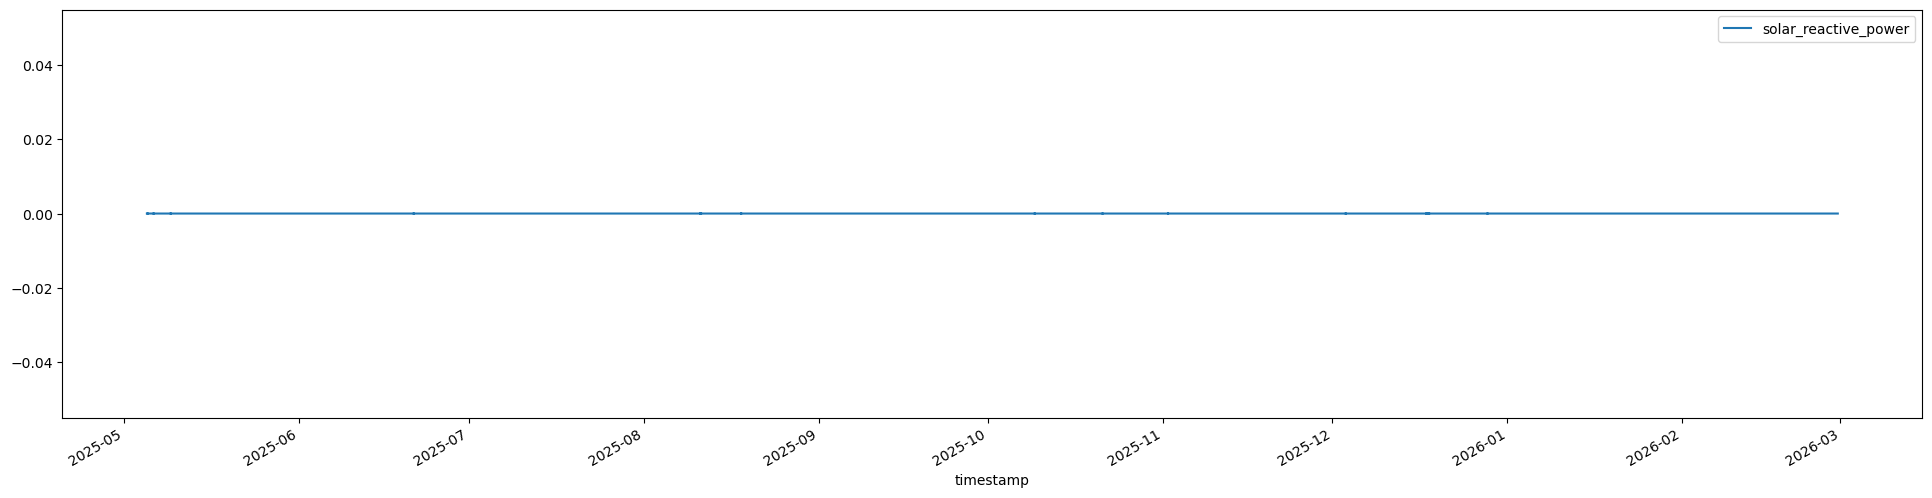

In [ ]:
# Test
all_data[all_data['pseudonym'] == 'SN001'].plot(x='timestamp', y='solar_reactive_power', figsize=(24,6))